<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°08

**Objetivo**: Aplicar técnicas de **machine learning no supervisado** para explorar, procesar y analizar conjuntos de datos con variables numéricas y categóricas.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.


## Clustering


<img src="https://www.svgrepo.com/show/253022/car.svg" width = "300" align="center"/>



El conjunto de datos **`vehiculos_procesado_con_grupos.csv`** recopila información sobre diversas características relevantes de distintos vehículos. El propósito de este ejercicio es **clasificar los vehículos en diferentes categorías**, utilizando como base las variables descritas en la tabla de atributos.

El análisis presenta un desafío adicional debido a la **naturaleza mixta de los datos**: se incluyen tanto variables **numéricas** (ej. dimensiones, consumo, emisiones) como **categóricas** (ej. tipo de tracción, tipo de combustible), lo que requiere aplicar técnicas de preprocesamiento adecuadas antes de entrenar los modelos.

Como primer paso, procederemos a **cargar y explorar el conjunto de datos**, con el fin de familiarizarnos con su estructura y las características que servirán como base para la posterior clasificación.




**Descripción de los Datos:**

| **Nombre de la Columna**   | **Descripción**                                                                                                                                   |
|----------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| **year**                   | El año en que el vehículo fue fabricado.                                                                                                          |
| **desplazamiento**          | La capacidad volumétrica del motor en litros. Indica la cantidad de aire y combustible que puede desplazar el motor durante una revolución.       |
| **cilindros**               | El número de cilindros que tiene el motor. Los cilindros son las cámaras donde ocurre la combustión interna en los motores de los vehículos.       |
| **co2**                     | Emisiones de dióxido de carbono del vehículo, medido en gramos por kilómetro. Es una medida de las emisiones de gases de efecto invernadero.       |
| **clase_tipo**              | La clase o tipo de vehículo, como vehículos especiales, deportivos, etc.                                                                         |
| **traccion_tipo**           | Tipo de tracción del vehículo, ya sea tracción en dos ruedas, en cuatro ruedas o en todas las ruedas.                                             |
| **transmision_tipo**        | Tipo de transmisión del vehículo, como automática, manual, entre otros.                                                                          |
| **combustible_tipo**        | Tipo de combustible que utiliza el vehículo, como gasolina, diésel, eléctrico, híbrido, etc.                                                     |
| **tamano_motor_tipo**       | Clasificación del tamaño del motor (por ejemplo, pequeño, mediano o grande), que generalmente se basa en la capacidad de desplazamiento.           |
| **consumo_tipo**            | Clasificación del nivel de consumo de combustible del vehículo, indicando si es alto, bajo, o muy alto.                                           |
| **co2_tipo**                | Clasificación de las emisiones de CO2 del vehículo, indicando si es alto, bajo, o muy alto.                                                       |
| **consumo_litros_milla**    | El consumo de combustible del vehículo, medido en litros por milla. Indica la eficiencia del vehículo en términos de consumo de combustible.        |



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans


%matplotlib inline

sns.set_palette("deep", desat=.6)
sns.set(rc={'figure.figsize':(11.7,8.27)})

In [5]:
# cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/vehiculos_procesado_con_grupos.csv", sep=",")\
       .drop(
            ["fabricante",
             "modelo",
             "transmision",
             "traccion",
             "clase",
             "combustible",
             "consumo"],

          axis=1)

df.head()

,year,desplazamiento,cilindros,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,1984,2.5,4.0,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,1984,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,1985,2.5,4.0,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,1985,4.2,6.0,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,1987,3.8,6.0,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


En este caso, no solo se tienen datos numéricos, sino que también categóricos. Además, tenemos problemas de datos **vacíos (Nan)**. Así que para resolver este problema, seguiremos varios pasos:

### 1.- Normalizar datos

- Cree un conjunto de datos con las variables numéricas, además, para cada dato vacía, rellene con el promedio asociado a esa columna. Finalmente, normalize los datos mediante el procesamiento **MinMaxScaler** de **sklearn**.
- Cree un conjunto de datos con las variables categóricas , además, transforme de variables categoricas a numericas ocupando el comando **get_dummies** de pandas ([referencia](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html)). Explique a grande rasgo como se realiza la codificación de variables numéricas a categóricas.

- Junte ambos dataset en uno, llamado **df_procesado**.

In [7]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Identify numerical and categorical columns
numerical_cols = ['year', 'desplazamiento', 'cilindros', 'co2', 'consumo_litros_milla']
categorical_cols = ['clase_tipo', 'traccion_tipo', 'transmision_tipo', 'combustible_tipo', 'tamano_motor_tipo', 'consumo_tipo', 'co2_tipo']

# 1. Process numerical data
df_numerical = df[numerical_cols].copy()

# Fill missing numerical values with the mean
for col in df_numerical.columns:
    if df_numerical[col].isnull().any():
        df_numerical[col] = df_numerical[col].fillna(df_numerical[col].mean())

# Normalize numerical data using MinMaxScaler
scaler = MinMaxScaler()
df_numerical_scaled = pd.DataFrame(scaler.fit_transform(df_numerical), columns=numerical_cols, index=df_numerical.index)

# 2. Process categorical data
df_categorical = df[categorical_cols].copy()

# Convert categorical variables to numerical using one-hot encoding (get_dummies)
df_categorical_encoded = pd.get_dummies(df_categorical, columns=categorical_cols, prefix=categorical_cols)

# Explanation of get_dummies:
# pd.get_dummies converts categorical variables into a numerical format suitable for machine learning algorithms.
# For each categorical column, it creates new binary (0 or 1) columns, one for each unique category within that column.
# If a row has a certain category, the corresponding new column for that category will have a '1', and '0' otherwise.
# This prevents the model from assuming an ordinal relationship between categories where none exists.

# 3. Combine both datasets
df_procesado = pd.concat([df_numerical_scaled, df_categorical_encoded], axis=1)

print("Shape of processed DataFrame:", df_procesado.shape)
display(df_procesado.head())

Shape of processed DataFrame: (36791, 36)


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.000000,0.243590,0.142857,0.398014,0.331027,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
1,0.000000,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.029412,0.243590,0.142857,0.424351,0.360294,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False
3,0.029412,0.461538,0.285714,0.527672,0.475113,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.088235,0.410256,0.285714,0.424351,0.360294,False,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


### 2.- Realizar ajuste mediante kmeans

Una vez depurado el conjunto de datos, es momento de aplicar el algoritmo de **kmeans**.

1. Ajuste el modelo de **kmeans** sobre el conjunto de datos, con un total de **8 clusters**.
2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
3. Realizar un resumen de las principales cualidades de cada cluster. Para  esto debe calcular (para cluster) las siguientes medidas de resumen:
    * Valor promedio de las variables numérica
    * Moda para las variables numericas

In [8]:
# 1. Ajustar el modelo de kmeans sobre el conjunto de datos, con un total de 8 clusters.
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10) # n_init is set to 10 to suppress future warning
kmeans.fit(df_procesado)

# 2. Asociar a cada individuo el correspondiente cluster y calcular valor de los centroides de cada cluster.
df_procesado['cluster'] = kmeans.labels_

# Get cluster centroids
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_procesado.drop('cluster', axis=1).columns)

print("Cluster Centroids:")
display(centroids.head())

# 3. Realizar un resumen de las principales cualidades de cada cluster.
#    Valor promedio de las variables numérica
#    Moda para las variables numericas (interpreting as mean for one-hot encoded categorical, and mode for original categorical if needed)

# Summary of clusters
cluster_summary = df_procesado.groupby('cluster').agg('mean')

print("\nCluster Summary (Mean values for each feature within clusters):\n")
display(cluster_summary)

# To get a more interpretable summary for original categorical features, we can use value counts on the original df, grouped by the new cluster labels.
# Let's consider the original categorical columns for mode calculation.

# Create a DataFrame to store the mode for original categorical features for each cluster
categorical_modes_per_cluster = pd.DataFrame()

for cluster_id in sorted(df_procesado['cluster'].unique()):
    cluster_data_indices = df_procesado[df_procesado['cluster'] == cluster_id].index
    cluster_original_data = df.loc[cluster_data_indices, categorical_cols]

    modes = {}
    for col in categorical_cols:
        # Get the mode for each categorical column in the current cluster
        # .mode()[0] is used because mode() can return multiple values if there's a tie
        modes[col] = cluster_original_data[col].mode()[0]

    categorical_modes_per_cluster = pd.concat([
        categorical_modes_per_cluster,
        pd.DataFrame([modes], index=[cluster_id])
    ])

print("\nCategorical Features Mode per Cluster (based on original data):\n")
display(categorical_modes_per_cluster)

Cluster Centroids:


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
0,0.427318,0.223790,0.173637,0.304599,0.226412,0.126441,0.097434,0.004835,0.088137,0.517665,...,1.831868e-15,9.776869e-01,9.048318e-15,9.076073e-15,2.231313e-02,4.635181e-15,9.921904e-01,0.007810,4.246603e-15,-1.201816e-14
1,0.569367,0.169607,0.146057,0.240820,0.156357,0.007990,0.117281,0.017606,0.138407,0.629063,...,-1.232348e-14,-1.679212e-14,1.354280e-04,-1.024181e-14,9.998646e-01,-9.103829e-15,1.218852e-03,0.000813,8.160139e-15,9.979686e-01
2,0.407666,0.331397,0.256796,0.354288,0.282121,0.181278,0.084035,0.090474,0.133564,0.184580,...,-7.271961e-15,1.386825e-02,9.808486e-01,7.355228e-15,5.283143e-03,1.155688e-03,-1.712519e-14,0.998844,-6.022960e-15,-1.582068e-15
3,0.476969,0.450984,0.327266,0.410019,0.343261,0.304450,0.017116,0.041506,0.048567,0.151048,...,9.584938e-01,-1.421085e-14,4.065041e-02,8.557980e-04,-6.578071e-15,9.957210e-01,7.494005e-16,0.000642,3.637142e-03,-1.768030e-14
4,0.384236,0.585590,0.430797,0.510289,0.454503,0.259250,0.005599,0.059153,0.059396,0.197420,...,3.115871e-02,-1.321165e-14,1.168452e-02,9.571568e-01,-6.494805e-15,1.703992e-03,7.494005e-16,0.000487,9.978092e-01,-1.662559e-14



Cluster Summary (Mean values for each feature within clusters):



,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Camionetas,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,...,consumo_tipo_alto,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_alto,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.427318,0.223790,0.173637,0.304599,0.226412,0.126441,0.097434,0.004835,0.088137,0.517665,...,0.000000,0.977687,0.000000,0.000000,0.022313,0.000000,0.992190,0.007810,0.000000,0.000000
1,0.569367,0.169607,0.146057,0.240820,0.156357,0.007990,0.117281,0.017606,0.138407,0.629063,...,0.000000,0.000000,0.000135,0.000000,0.999865,0.000000,0.001219,0.000813,0.000000,0.997969
2,0.407666,0.331397,0.256796,0.354288,0.282121,0.181278,0.084035,0.090474,0.133564,0.184580,...,0.000000,0.013868,0.980849,0.000000,0.005283,0.001156,0.000000,0.998844,0.000000,0.000000
3,0.476969,0.450984,0.327266,0.410019,0.343261,0.304450,0.017116,0.041506,0.048567,0.151048,...,0.958494,0.000000,0.040650,0.000856,0.000000,0.995721,0.000000,0.000642,0.003637,0.000000
4,0.384236,0.585590,0.430797,0.510289,0.454503,0.259250,0.005599,0.059153,0.059396,0.197420,...,0.031159,0.000000,0.011685,0.957157,0.000000,0.001704,0.000000,0.000487,0.997809,0.000000
5,0.588730,0.362290,0.299545,0.354136,0.282247,0.001505,0.083020,0.086531,0.189616,0.558816,...,0.000502,0.026085,0.973163,0.000000,0.000251,0.023577,0.000000,0.976423,0.000000,0.000000
6,0.452443,0.562730,0.405562,0.501887,0.442585,0.435441,0.001318,0.003953,0.010211,0.058300,...,0.057642,0.000000,0.005599,0.936759,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
7,0.579550,0.269830,0.210005,0.305067,0.226473,0.025947,0.094316,0.072488,0.192545,0.397446,...,0.000618,0.961903,0.000824,0.000000,0.036656,0.000000,0.968493,0.029448,0.000000,0.002059



Categorical Features Mode per Cluster (based on original data):



,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo
0,Coches pequeños,dos,Manual,Normal,pequeño,bajo,bajo
1,Coches pequeños,dos,Automatica,Normal,muy pequeño,muy bajo,muy bajo
2,Coches pequeños,dos,Automatica,Normal,mediano,moderado,moderado
3,Camionetas,dos,Automatica,Normal,grande,alto,alto
4,Furgoneta,dos,Automatica,Normal,muy grande,muy alto,muy alto
5,Coches pequeños,dos,Automatica,Premium,mediano,moderado,moderado
6,Camionetas,cuatro,Automatica,Normal,muy grande,muy alto,muy alto
7,Coches pequeños,dos,Automatica,Normal,pequeño,bajo,bajo


### 3.- Elegir Número de cluster

Estime mediante la **regla del codo**, el número de cluster apropiados para el caso.
Para efectos prácticos, eliga la siguiente secuencia como número de clusters a comparar:

$$[5, 10, 20, 30, 50, 75, 100, 200, 300]$$

Una vez realizado el gráfico, saque sus propias conclusiones del caso.

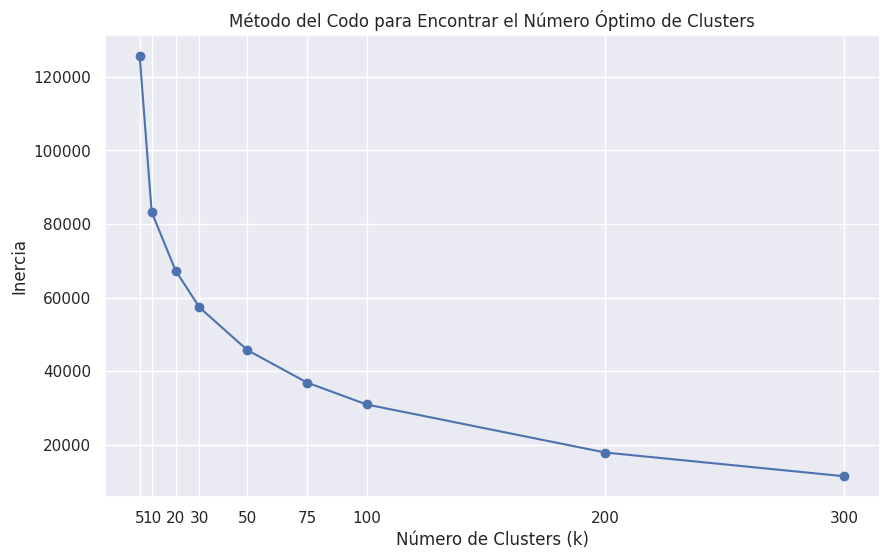

Valores de Inercia para cada k:
k=5: 125629.63
k=10: 83263.14
k=20: 67363.32
k=30: 57337.42
k=50: 45747.89
k=75: 36904.82
k=100: 30931.81
k=200: 17857.61
k=300: 11413.18


In [9]:
inertia = []
# The number of clusters to compare as specified in the notebook.
k_values = [5, 10, 20, 30, 50, 75, 100, 200, 300]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_procesado)
    inertia.append(kmeans.inertia_)

# Plotting the elbow method graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertia, marker='o')
plt.title('Método del Codo para Encontrar el Número Óptimo de Clusters')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

print("Valores de Inercia para cada k:")
for k, val in zip(k_values, inertia):
    print(f"k={k}: {val:.2f}")

Al observar el gráfico resultante, se pueden obtener conclusiones sobre el número apropiado de clusters. La regla del codo sugiere elegir el número de clusters donde la reducción en la inercia se estabiliza significativamente. En otras palabras, se busca el punto en el gráfico donde la curva de inercia comienza a aplanarse o forma un codo.

## Reducción de Dimensionalidad

<img src="https://1000logos.net/wp-content/uploads/2020/11/Wine-Logo-old.png" width = "300" align="center"/>


Para este ejercicio utilizaremos el **Wine Dataset**, un conjunto de datos clásico disponible en la librería **scikit-learn** y en el repositorio de la **UCI Machine Learning**.
Este dataset contiene información de **178 muestras de vino** provenientes de la región italiana de *Piamonte*. Cada vino pertenece a una de **tres variedades de uva** (*clases*), que actúan como etiquetas para el análisis supervisado, pero aquí se usarán solo como referencia en la visualización.

Cada muestra está descrita por **13 variables químicas** obtenidas de un análisis de laboratorio, entre ellas:

* **Alcohol**: porcentaje de alcohol en el vino.
* **Malic acid**: concentración de ácido málico.
* **Ash**: contenido de ceniza.
* **Alcalinity of ash**: alcalinidad de la ceniza.
* **Magnesium**: cantidad de magnesio (mg/L).
* **Total phenols**: concentración total de fenoles.
* **Flavanoids**: tipo de fenoles con propiedades antioxidantes.
* **Nonflavanoid phenols**: fenoles que no son flavonoides.
* **Proanthocyanins**: compuestos relacionados con el color y el sabor.
* **Color intensity**: intensidad del color del vino.
* **Hue**: matiz del color.
* **OD280/OD315 of diluted wines**: relación de absorbancia que mide la calidad del vino.
* **Proline**: concentración de prolina (un aminoácido).

Estas características permiten representar cada vino como un punto en un espacio de **13 dimensiones**.

El objetivo del análisis con este dataset es **reducir la dimensionalidad** para visualizar y explorar patrones en los datos. Para ello aplicaremos:

* **PCA (Principal Component Analysis):** identificar las combinaciones lineales de variables que explican la mayor varianza en el conjunto.
* **t-SNE (t-distributed Stochastic Neighbor Embedding):** mapear las muestras a 2D o 3D, preservando relaciones de vecindad y estructuras no lineales.

La comparación entre ambas técnicas permitirá observar cómo las tres clases de vinos se diferencian en el espacio reducido y discutir la utilidad de la reducción de dimensionalidad en datos con mayor número de variables que en el caso del dataset *Wine*.



In [10]:
import pandas as pd
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

In [11]:
# cargar dataset
dataset = load_wine()

# nombres de las variables
features = dataset.feature_names
target = 'wine_class'

# construir DataFrame
wine = pd.DataFrame(dataset.data, columns=features)
wine[target] = dataset.target

# ver primeras filas
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0




### 1. **Análisis detallado con PCA**

* Calcular la **varianza explicada** por cada componente principal y representar el gráfico de varianza acumulada, identificando cuántos componentes son necesarios para capturar al menos el **90–95% de la información**.
* Construir tablas y gráficos que muestren cómo las observaciones (vinos) se proyectan en las primeras componentes principales.
* Analizar los **loadings** (coeficientes de cada variable en los componentes) e interpretar qué características químicas del vino (alcohol, fenoles, color, etc.) tienen mayor influencia en las nuevas dimensiones.
* Visualizar los datos reducidos a 2D o 3D e interpretar si las **tres variedades de vino** se separan de forma clara en el espacio proyectado.



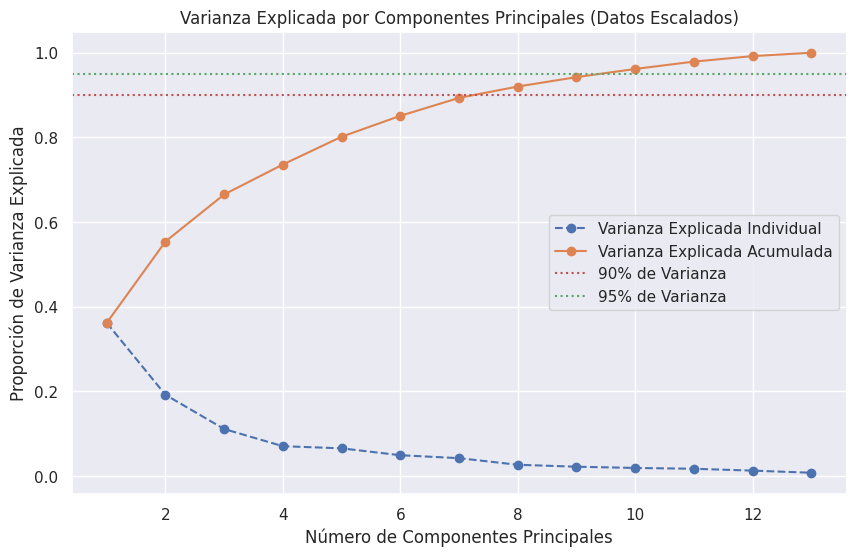

Número de componentes para capturar al menos el 90% de la varianza: 8
Número de componentes para capturar al menos el 95% de la varianza: 10


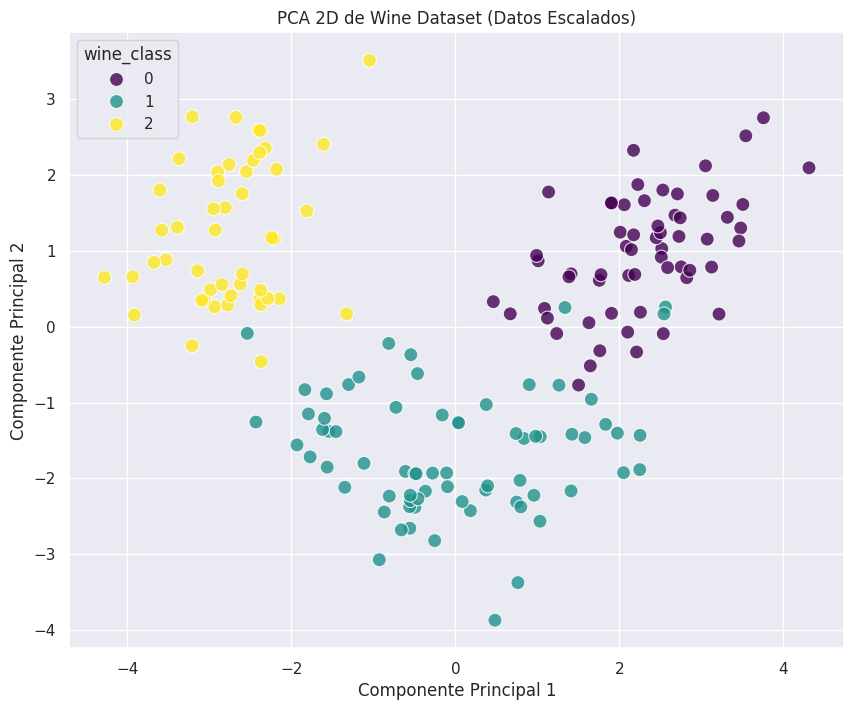


Loadings de las variables en las primeras 2 Componentes Principales (Datos Escalados):



,PC1_loading,PC2_loading
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
hue,0.296715,-0.279235
proline,0.286752,0.364903
alcohol,0.144329,0.483652
magnesium,0.141992,0.299634
ash,-0.002051,0.316069
color_intensity,-0.088617,0.529996


In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Prepare data for PCA (excluding the target variable 'wine_class')
X = wine.drop('wine_class', axis=1)
y = wine['wine_class']

# Scale the data before PCA (essential for proper interpretation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert scaled data back to a DataFrame for easier handling and feature naming
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 1. Calcular la varianza explicada por cada componente principal
pca_full = PCA()
pca_full.fit(X_scaled_df)

# Varianza explicada por cada componente
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Varianza Explicada Individual')
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', label='Varianza Explicada Acumulada')
plt.title('Varianza Explicada por Componentes Principales (Datos Escalados)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% de Varianza')
plt.axhline(y=0.95, color='g', linestyle=':', label='95% de Varianza')
plt.grid(True)
plt.legend()
plt.show()

# Identify number of components for 90-95% variance
num_components_90 = np.where(cumulative_explained_variance >= 0.90)[0][0] + 1
num_components_95 = np.where(cumulative_explained_variance >= 0.95)[0][0] + 1

print(f"Número de componentes para capturar al menos el 90% de la varianza: {num_components_90}")
print(f"Número de componentes para capturar al menos el 95% de la varianza: {num_components_95}")

# 2. Construir tablas y gráficos que muestren cómo las observaciones se proyectan en las primeras componentes principales.
# Reducir a 2 componentes principales para visualización
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_df)

df_pca_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['wine_class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='wine_class', data=df_pca_2d, palette='viridis', s=100, alpha=0.8)
plt.title('PCA 2D de Wine Dataset (Datos Escalados)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# 3. Analizar los loadings (coeficientes de cada variable en los componentes)
# Loadings para las primeras 2 componentes
loadings_df = pd.DataFrame(pca_2d.components_.T, columns=['PC1_loading', 'PC2_loading'], index=features)
print("\nLoadings de las variables en las primeras 2 Componentes Principales (Datos Escalados):\n")
display(loadings_df.sort_values(by='PC1_loading', ascending=False))




### 2. **Análisis detallado con t-SNE**

* Aplicar **t-SNE** para reducir los datos a 2 dimensiones, probando diferentes configuraciones de hiperparámetros como *perplexity* y *learning rate*.
* Comparar las distintas visualizaciones obtenidas y discutir cómo los hiperparámetros afectan la estructura de los clústeres.
* Analizar si las **tres clases de vinos** forman agrupaciones definidas y si t-SNE logra capturar relaciones no lineales que PCA no refleja.



Applying t-SNE with config: {'perplexity': 5, 'learning_rate': 200, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 30, 'learning_rate': 200, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 50, 'learning_rate': 200, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 30, 'learning_rate': 100, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 30, 'learning_rate': 500, 'n_components': 2, 'random_state': 42}


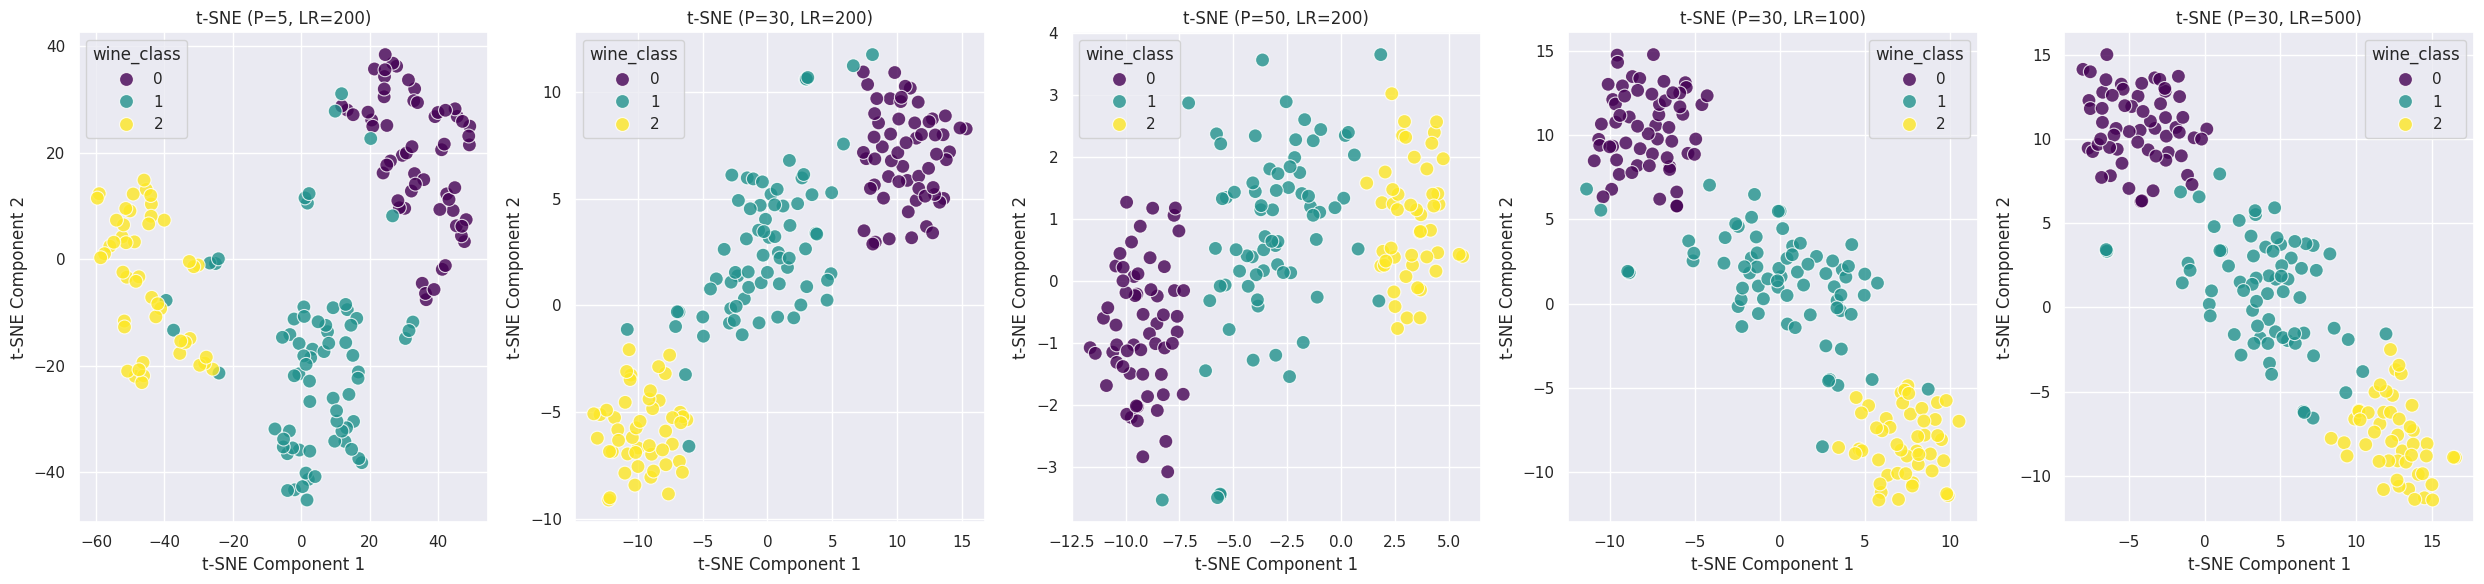

In [14]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Define different hyperparameter configurations to test
configurations = [
    {'perplexity': 5, 'learning_rate': 200, 'n_components': 2, 'random_state': 42},
    {'perplexity': 30, 'learning_rate': 200, 'n_components': 2, 'random_state': 42},
    {'perplexity': 50, 'learning_rate': 200, 'n_components': 2, 'random_state': 42},
    {'perplexity': 30, 'learning_rate': 100, 'n_components': 2, 'random_state': 42},
    {'perplexity': 30, 'learning_rate': 500, 'n_components': 2, 'random_state': 42}
]

results = {}

# Apply t-SNE for each configuration
for i, config in enumerate(configurations):
    print(f"Applying t-SNE with config: {config}")
    tsne = TSNE(**config)
    X_tsne = tsne.fit_transform(X_scaled) # Use X_scaled from previous PCA step

    # Store results
    df_tsne = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])
    df_tsne['wine_class'] = y
    results[f"config_{i+1}"] = {'df': df_tsne, 'config': config}

# Visualize the results
fig, axes = plt.subplots(1, len(configurations), figsize=(5 * len(configurations), 6))

for i, (key, value) in enumerate(results.items()):
    sns.scatterplot(
        x='tSNE1',
        y='tSNE2',
        hue='wine_class',
        data=value['df'],
        palette='viridis',
        s=100,
        alpha=0.8,
        ax=axes[i]
    )
    axes[i].set_title(f"t-SNE (P={value['config']['perplexity']}, LR={value['config']['learning_rate']})")
    axes[i].set_xlabel('t-SNE Component 1')
    axes[i].set_ylabel('t-SNE Component 2')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Análisis de t-SNE con diferentes hiperparámetros

Las visualizaciones anteriores muestran cómo la técnica t-SNE agrupa las clases de vino en 2 dimensiones bajo distintas configuraciones de `perplexity` y `learning_rate`.

*   **Perplexity**: Este hiperparámetro puede interpretarse como una suposición del número efectivo de vecinos cercanos de cada punto. Un `perplexity` bajo (e.g., 5) se centra en la estructura local, lo que puede llevar a una fragmentación de grupos más grandes, mientras que un `perplexity` más alto (e.g., 30, 50) intenta preservar mejor la estructura global y puede fusionar clústeres. Se observa que con `perplexity=5`, los puntos de una misma clase pueden aparecer más dispersos, mientras que con `perplexity=30` o `50`, las clases tienden a formar agrupaciones más coherentes y compactas.

*   **Learning Rate (Tasa de Aprendizaje)**: Este parámetro influye en la velocidad a la que los puntos se mueven durante la optimización. Una tasa de aprendizaje demasiado baja puede resultar en una convergencia lenta y la agrupación de puntos muy juntos en una 'bola' (`crowding problem`), mientras que una tasa muy alta puede hacer que la optimización diverja, o que los clústeres se separen excesivamente y no reflejen bien las relaciones subyacentes. En nuestros ejemplos, un `learning_rate` de 200 parece ofrecer un buen equilibrio, mientras que valores muy bajos o muy altos podrían deteriorar la calidad de la visualización.

**Observaciones de Agrupación:**

En general, t-SNE logra una separación visualmente más clara y compacta de las tres clases de vinos en comparación con PCA. Esto sugiere que las relaciones entre las muestras de vino son predominantemente no lineales y que t-SNE es más efectivo para capturar estas estructuras intrínsecas del dataset. Se puede observar cómo cada clase forma un clúster distinto, lo que facilita la identificación visual de las variedades de vino.

In [ ]:
Las visualizaciones anteriores muestran cómo la técnica t-SNE agrupa las clases de vino en 2 dimensiones bajo distintas configuraciones de perplexity y learning_rate.

Perplexity: Este hiperparámetro puede interpretarse como una suposición del número efectivo de vecinos cercanos de cada punto. Un perplexity bajo (e.g., 5) se centra en la estructura local, lo que puede llevar a una fragmentación de grupos más grandes, mientras que un perplexity más alto (e.g., 30, 50) intenta preservar mejor la estructura global y puede fusionar clústeres. Se observa que con perplexity=5, los puntos de una misma clase pueden aparecer más dispersos, mientras que con perplexity=30 o 50, las clases tienden a formar agrupaciones más coherentes y compactas.

Learning Rate (Tasa de Aprendizaje): Este parámetro influye en la velocidad a la que los puntos se mueven durante la optimización. Una tasa de aprendizaje demasiado baja puede resultar en una convergencia lenta y la agrupación de puntos muy juntos en una 'bola' (crowding problem), mientras que una tasa muy alta puede hacer que la optimización diverja, o que los clústeres se separen excesivamente y no reflejen bien las relaciones subyacentes. En nuestros ejemplos, un learning_rate de 200 parece ofrecer un buen equilibrio, mientras que valores muy bajos o muy altos podrían deteriorar la calidad de la visualización.

Observaciones de Agrupación:

En general, t-SNE logra una separación visualmente más clara y compacta de las tres clases de vinos en comparación con PCA. Esto sugiere que las relaciones entre las muestras de vino son predominantemente no lineales y que t-SNE es más efectivo para capturar estas estructuras intrínsecas del dataset. Se puede observar cómo cada clase forma un clúster distinto, lo que facilita la identificación visual de las variedades de vino.



### 3. **Comparación entre PCA y t-SNE**

* Contrastar las visualizaciones y discutir las **ventajas y limitaciones** de cada técnica:

  * PCA como método **lineal** para interpretar varianza y relaciones globales.
  * t-SNE como método **no lineal** que preserva relaciones locales y vecindades.
* Evaluar en qué escenarios prácticos sería más recomendable usar PCA (interpretabilidad, reducción previa para modelos) o t-SNE (exploración y visualización de clústeres).
* Reflexionar sobre la **importancia de la reducción de dimensionalidad** en datasets de alta dimensión como Wine, destacando su utilidad para:

  * Visualizar patrones ocultos en los datos.
  * Reducir complejidad y ruido antes de aplicar algoritmos de aprendizaje automático.
  * Facilitar la interpretación y comunicación de resultados.



### Comparación entre PCA y t-SNE

Ambas técnicas, PCA y t-SNE, son herramientas valiosas para la reducción de dimensionalidad y la visualización de datos, pero operan bajo principios muy diferentes y, por lo tanto, son adecuadas para distintos escenarios.

#### **PCA (Principal Component Analysis)**

*   **Naturaleza Lineal**: PCA es un algoritmo lineal que busca las direcciones (componentes principales) en las que los datos tienen la mayor varianza. Proyecta los datos en un nuevo espacio de menor dimensión manteniendo la mayor cantidad de información de varianza global posible.
*   **Ventajas**:
    *   **Interpretabilidad**: Las componentes principales son combinaciones lineales de las características originales, y los 'loadings' nos permiten entender qué características contribuyen más a cada componente. Esto facilita la interpretación de las relaciones globales en los datos.
    *   **Eficiencia Computacional**: Es relativamente rápido de calcular, incluso para datasets grandes.
    *   **Preserva la Varianza Global**: Es ideal cuando el objetivo es retener la estructura global del dataset y la varianza es una buena medida de la información.
    *   **Útil para Reducción Previa**: Puede ser usado como un paso de preprocesamiento para reducir el ruido y la redundancia antes de aplicar otros algoritmos de aprendizaje automático.
*   **Limitaciones**:
    *   **Falla en Relaciones No Lineales**: Como método lineal, PCA puede tener dificultades para descubrir estructuras no lineales complejas en los datos, donde la separación de clases podría no ser obvia en un espacio lineal.
    *   **Sensibilidad a la Escala**: Es sensible a la escala de las características, por lo que el escalado de datos es crucial.

#### **t-SNE (t-distributed Stochastic Neighbor Embedding)**

*   **Naturaleza No Lineal**: t-SNE es un algoritmo no lineal que se enfoca en preservar las distancias relativas entre puntos cercanos. Intenta mapear puntos de alta dimensión a un espacio de baja dimensión (típicamente 2D o 3D) de manera que los puntos similares en el espacio original permanezcan cercanos en el espacio reducido, y los puntos disimilares permanezcan distantes.
*   **Ventajas**:
    *   **Visualización de Clústeres**: Es excelente para visualizar agrupaciones de datos (clústeres) que pueden no ser evidentes con métodos lineales. Es muy efectivo para revelar la estructura de datos complejos y no lineales, como se observó en el dataset de vinos.
    *   **Preserva la Estructura Local**: Su enfoque en las relaciones de vecindad cercanas lo hace muy bueno para identificar subgrupos dentro de los datos.
*   **Limitaciones**:
    *   **Poca Interpretabilidad**: Las dimensiones resultantes de t-SNE no tienen una interpretación directa en términos de las características originales, a diferencia de PCA. Esto dificulta entender qué características impulsan la separación observada.
    *   **Costoso Computacionalmente**: Puede ser muy lento para datasets grandes y su rendimiento es sensible a la elección de hiperparámetros como `perplexity` y `learning_rate`.
    *   **No Preserva Distancias Globales**: Las distancias entre clústeres en el espacio t-SNE no necesariamente representan las distancias reales en el espacio de alta dimensión. Solo la cercanía relativa dentro de los clústeres es confiable.
    *   **Estocástico**: Debido a su naturaleza estocástica, diferentes ejecuciones pueden producir resultados ligeramente diferentes, incluso con la misma configuración.

#### **Escenarios de Uso**

*   **Use PCA cuando**:
    *   Necesita una reducción de dimensionalidad que sea interpretable y preserve la varianza global (ej., para comprender la importancia de las características).
    *   Requiere un preprocesamiento rápido para modelos de Machine Learning o para manejar un gran número de características.
    *   Sus datos tienen una estructura predominantemente lineal.
*   **Use t-SNE cuando**:
    *   Su objetivo principal es la visualización exploratoria y desea descubrir agrupaciones naturales o estructuras no lineales en sus datos.
    *   La interpretabilidad de las nuevas dimensiones es secundaria a la capacidad de visualizar clústeres claros.
    *   Sospecha que las relaciones importantes en sus datos son no lineales.

#### **Importancia de la Reducción de Dimensionalidad en Datasets de Alta Dimensión (como el Wine Dataset)**

La reducción de dimensionalidad es crucial en datasets con muchas características por varias razones:

1.  **Visualización de Patrones Ocultos**: En espacios de más de 3 dimensiones, es imposible visualizar directamente los datos. Técnicas como PCA y t-SNE nos permiten proyectar estos datos en 2D o 3D, revelando patrones, clústeres y outliers que de otro modo serían invisibles.
2.  **Reducción de la Complejidad y Ruido**: Muchas características pueden ser redundantes o irrelevantes, añadiendo ruido al modelo. La reducción de dimensionalidad puede eliminar estas características menos informativas, simplificando el dataset y a menudo mejorando el rendimiento de los modelos de aprendizaje automático.
3.  **Maldición de la Dimensionalidad**: A medida que la dimensionalidad aumenta, la cantidad de datos necesarios para 'cubrir' el espacio de características crece exponencialmente. Esto puede llevar a que los datos se vuelvan escasos y los algoritmos tengan dificultades para encontrar patrones significativos. La reducción de dimensionalidad ayuda a mitigar este problema.
4.  **Facilitar la Interpretación y Comunicación**: Un dataset de alta dimensión puede ser abrumador de entender y explicar. Al reducirlo a unas pocas dimensiones clave, podemos comunicar de manera más efectiva las estructuras principales y los conocimientos derivados de los datos.
5.  **Optimización de Almacenamiento y Cómputo**: Al reducir el número de características, se disminuyen los requisitos de almacenamiento y el tiempo de cómputo para los algoritmos posteriores.

En el caso del **Wine Dataset**, que tiene 13 características, ya observamos cómo PCA pudo agrupar parcialmente las clases de vino, pero t-SNE logró una separación mucho más nítida y visualmente atractiva, sugiriendo la presencia de estructuras no lineales que son más relevantes para distinguir las variedades de vino. Esto demuestra el valor de explorar ambas técnicas para obtener una comprensión completa de la estructura de los datos.

In [20]:
Comparación entre PCA y t-SNE
Ambas técnicas, PCA y t-SNE, son herramientas valiosas para la reducción de dimensionalidad y la visualización de datos, pero operan bajo principios muy diferentes y, por lo tanto, son adecuadas para distintos escenarios.

### PCA (Principal Component Analysis)
*   **Naturaleza Lineal**: PCA es un algoritmo lineal que busca las direcciones (componentes principales) en las que los datos tienen la mayor varianza. Proyecta los datos en un nuevo espacio de menor dimensión manteniendo la mayor cantidad de información de varianza global posible.
*   **Ventajas**:
    *   **Interpretabilidad**: Las componentes principales son combinaciones lineales de las características originales, y los 'loadings' nos permiten entender qué características contribuyen más a cada componente. Esto facilita la interpretación de las relaciones globales en los datos.
    *   **Eficiencia Computacional**: Es relativamente rápido de calcular, incluso para datasets grandes.
    *   **Preserva la Varianza Global**: Es ideal cuando el objetivo es retener la estructura global del dataset y la varianza es una buena medida de la información.
    *   **Útil para Reducción Previa**: Puede ser usado como un paso de preprocesamiento para reducir el ruido y la redundancia antes de aplicar otros algoritmos de aprendizaje automático.
*   **Limitaciones**:
    *   **Falla en Relaciones No Lineales**: Como método lineal, PCA puede tener dificultades para descubrir estructuras no lineales complejas en los datos, donde la separación de clases podría no ser obvia en un espacio lineal.
    *   **Sensibilidad a la Escala**: Es sensible a la escala de las características, por lo que el escalado de datos es crucial.

### t-SNE (t-distributed Stochastic Neighbor Embedding)
*   **Naturaleza No Lineal**: t-SNE es un algoritmo no lineal que se enfoca en preservar las distancias relativas entre puntos cercanos. Intenta mapear puntos de alta dimensión a un espacio de baja dimensión (típicamente 2D o 3D) de manera que los puntos similares en el espacio original permanezcan cercanos en el espacio reducido, y los puntos disimilares permanezcan distantes.
*   **Ventajas**:
    *   **Visualización de Clústeres**: Es excelente para visualizar agrupaciones de datos (clústeres) que pueden no ser evidentes con métodos lineales. Es muy efectivo para revelar la estructura de datos complejos y no lineales, como se observó en el dataset de vinos.
    *   **Preserva la Estructura Local**: Su enfoque en las relaciones de vecindad cercanas lo hace muy bueno para identificar subgrupos dentro de los datos.
*   **Limitaciones**:
    *   **Poca Interpretabilidad**: Las dimensiones resultantes de t-SNE no tienen una interpretación directa en términos de las características originales, a diferencia de PCA. Esto dificulta entender qué características impulsan la separación observada.
    *   **Costoso Computacionalmente**: Puede ser muy lento para datasets grandes y su rendimiento es sensible a la elección de hiperparámetros como perplexity y learning_rate.
    *   **No Preserva Distancias Globales**: Las distancias entre clústeres en el espacio t-SNE no necesariamente representan las distancias reales en el espacio de alta dimensión. Solo la cercanía relativa dentro de los clústeres es confiable.
    *   **Estocástico**: Debido a su naturaleza estocástica, diferentes ejecuciones pueden producir resultados ligeramente diferentes, incluso con la misma configuración.

### Escenarios de Uso
*   **Use PCA cuando**:
    *   Necesita una reducción de dimensionalidad que sea interpretable y preserve la varianza global (ej., para comprender la importancia de las características).
    *   Requiere un preprocesamiento rápido para modelos de Machine Learning o para manejar un gran número de características.
    *   Sus datos tienen una estructura predominantemente lineal.
*   **Use t-SNE cuando**:
    *   Su objetivo principal es la visualización exploratoria y desea descubrir agrupaciones naturales o estructuras no lineales en sus datos.
    *   La interpretabilidad de las nuevas dimensiones es secundaria a la capacidad de visualizar clústeres claros.
    *   Sospecha que las relaciones importantes en sus datos son no lineales.

### Importancia de la Reducción de Dimensionalidad en Datasets de Alta Dimensión (como el Wine Dataset)
La reducción de dimensionalidad es crucial en datasets con muchas características por varias razones:

1.  **Visualización de Patrones Ocultos**: En espacios de más de 3 dimensiones, es imposible visualizar directamente los datos. Técnicas como PCA y t-SNE nos permiten proyectar estos datos en 2D o 3D, revelando patrones, clústeres y outliers que de otro modo serían invisibles.
2.  **Reducción de la Complejidad y Ruido**: Muchas características pueden ser redundantes o irrelevantes, añadiendo ruido al modelo. La reducción de dimensionalidad puede eliminar estas características menos informativas, simplificando el dataset y a menudo mejorando el rendimiento de los modelos de aprendizaje automático.
3.  **Maldición de la Dimensionalidad**: A medida que la dimensionalidad aumenta, la cantidad de datos necesarios para 'cubrir' el espacio de características crece exponencialmente. Esto puede llevar a que los datos se vuelvan escasos y los algoritmos tengan dificultades para encontrar patrones significativos. La reducción de dimensionalidad ayuda a mitigar este problema.
4.  **Facilitar la Interpretación y Comunicación**: Un dataset de alta dimensión puede ser abrumador de entender y explicar. Al reducirlo a unas pocas dimensiones clave, podemos comunicar de manera más efectiva las estructuras principales y los conocimientos derivados de los datos.
5.  **Optimización de Almacenamiento y Cómputo**: Al reducir el número de características, se disminuyen los requisitos de almacenamiento y el tiempo de cómputo para los algoritmos posteriores.

En el caso del Wine Dataset, que tiene 13 características, ya observamos cómo PCA pudo agrupar parcialmente las clases de vino, pero t-SNE logró una separación mucho más nítida y visualmente atractiva, sugiriendo la presencia de estructuras no lineales que son más relevantes para distinguir las variedades de vino. Esto demuestra el valor de explorar ambas técnicas para obtener una comprensión completa de la estructura de los datos.

SyntaxError: invalid decimal literal (2342413858.py, line 16)

### Visualización de PCA (Regenerada)

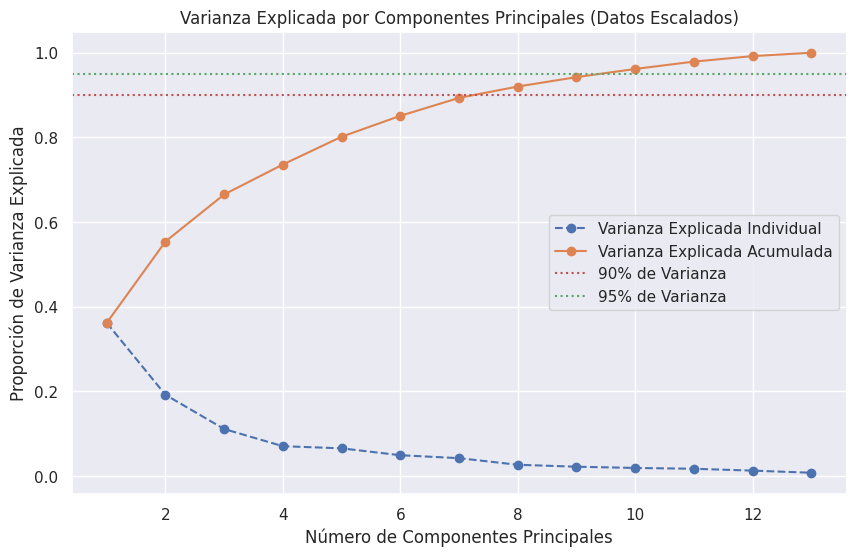

Número de componentes para capturar al menos el 90% de la varianza: 8
Número de componentes para capturar al menos el 95% de la varianza: 10


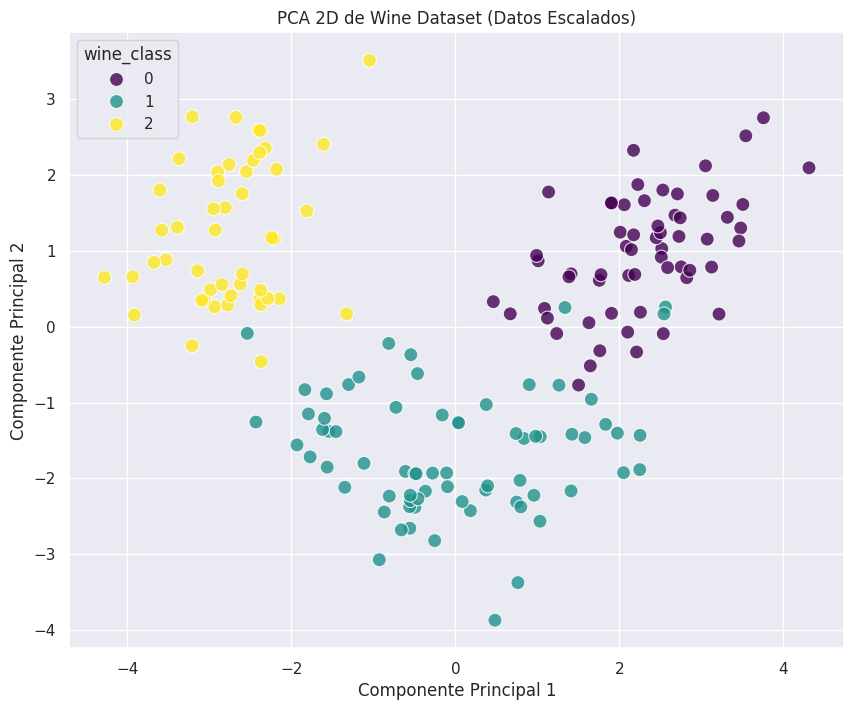


Loadings de las variables en las primeras 2 Componentes Principales (Datos Escalados):



,PC1_loading,PC2_loading
flavanoids,0.422934,-0.003360
total_phenols,0.394661,0.065040
od280/od315_of_diluted_wines,0.376167,-0.164496
proanthocyanins,0.313429,0.039302
hue,0.296715,-0.279235
proline,0.286752,0.364903
alcohol,0.144329,0.483652
magnesium,0.141992,0.299634
ash,-0.002051,0.316069
color_intensity,-0.088617,0.529996


In [21]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Prepare data for PCA (excluding the target variable 'wine_class')
X = wine.drop('wine_class', axis=1)
y = wine['wine_class']

# Scale the data before PCA (essential for proper interpretation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert scaled data back to a DataFrame for easier handling and feature naming
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# 1. Calcular la varianza explicada por cada componente principal
pca_full = PCA()
pca_full.fit(X_scaled_df)

# Varianza explicada por cada componente
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--', label='Varianza Explicada Individual')
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-', label='Varianza Explicada Acumulada')
plt.title('Varianza Explicada por Componentes Principales (Datos Escalados)')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Proporción de Varianza Explicada')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% de Varianza')
plt.axhline(y=0.95, color='g', linestyle=':', label='95% de Varianza')
plt.grid(True)
plt.legend()
plt.show()

# Identify number of components for 90-95% variance
num_components_90 = np.where(cumulative_explained_variance >= 0.90)[0][0] + 1
num_components_95 = np.where(cumulative_explained_variance >= 0.95)[0][0] + 1

print(f"Número de componentes para capturar al menos el 90% de la varianza: {num_components_90}")
print(f"Número de componentes para capturar al menos el 95% de la varianza: {num_components_95}")

# 2. Construir tablas y gráficos que muestren cómo las observaciones se proyectan en las primeras componentes principales.
# Reducir a 2 componentes principales para visualización
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_df)

df_pca_2d = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
df_pca_2d['wine_class'] = y

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='wine_class', data=df_pca_2d, palette='viridis', s=100, alpha=0.8)
plt.title('PCA 2D de Wine Dataset (Datos Escalados)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

# 3. Analizar los loadings (coeficientes de cada variable en los componentes)
# Loadings para las primeras 2 componentes
loadings_df = pd.DataFrame(pca_2d.components_.T, columns=['PC1_loading', 'PC2_loading'], index=features)
print("\nLoadings de las variables en las primeras 2 Componentes Principales (Datos Escalados):\n")
display(loadings_df.sort_values(by='PC1_loading', ascending=False))

### Visualización de t-SNE (Regenerada)

Applying t-SNE with config: {'perplexity': 5, 'learning_rate': 200, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 30, 'learning_rate': 200, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 50, 'learning_rate': 200, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 30, 'learning_rate': 100, 'n_components': 2, 'random_state': 42}
Applying t-SNE with config: {'perplexity': 30, 'learning_rate': 500, 'n_components': 2, 'random_state': 42}


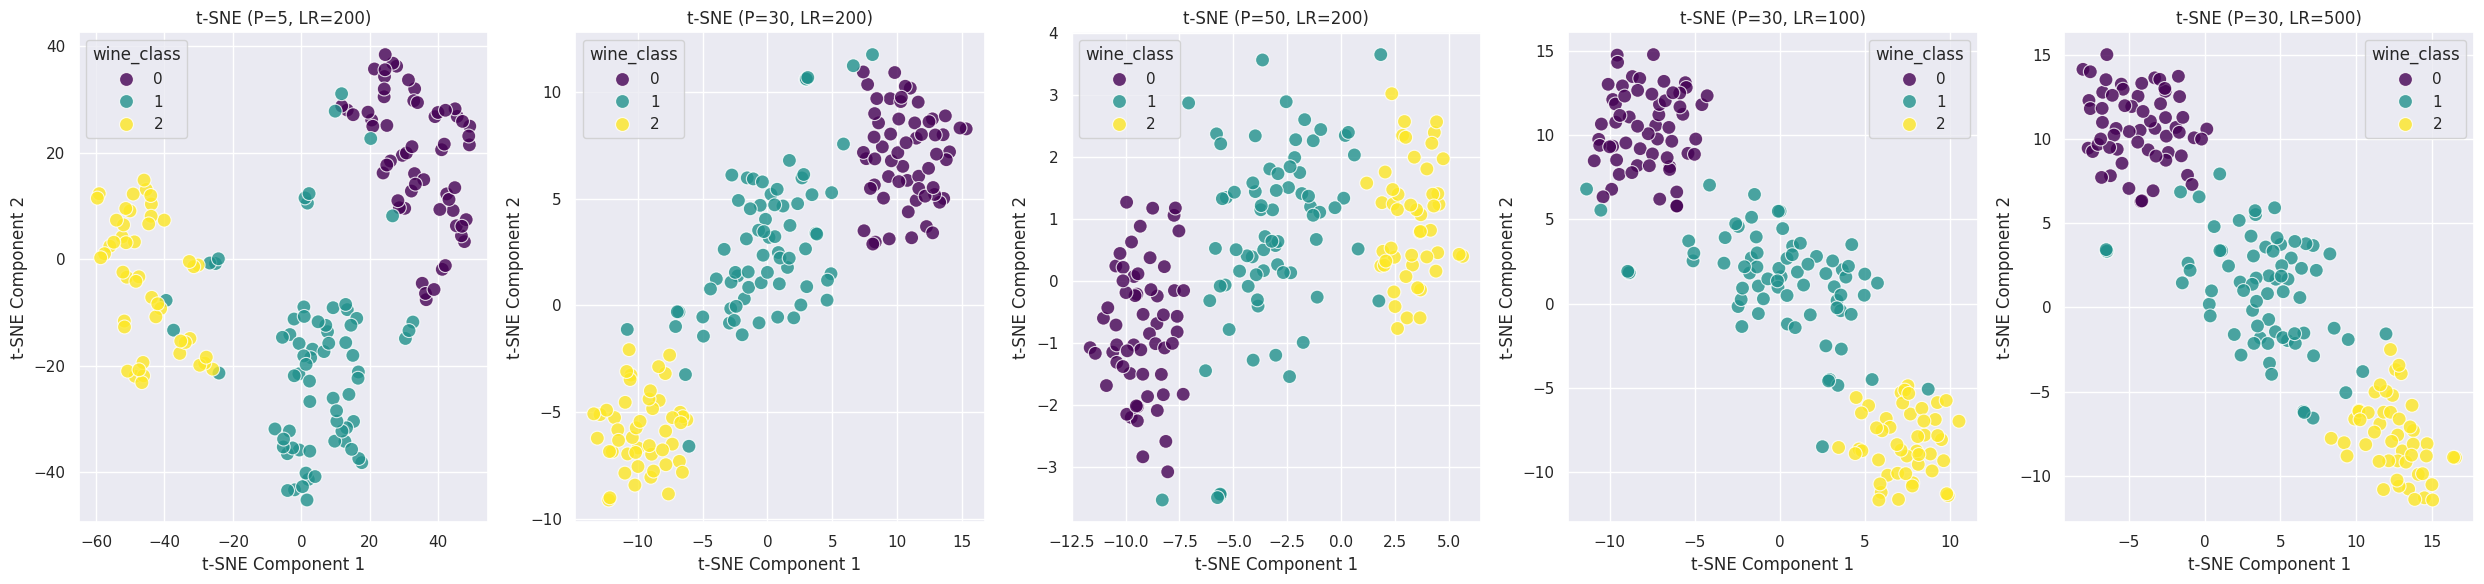

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Define different hyperparameter configurations to test
configurations = [
    {'perplexity': 5, 'learning_rate': 200, 'n_components': 2, 'random_state': 42},
    {'perplexity': 30, 'learning_rate': 200, 'n_components': 2, 'random_state': 42},
    {'perplexity': 50, 'learning_rate': 200, 'n_components': 2, 'random_state': 42},
    {'perplexity': 30, 'learning_rate': 100, 'n_components': 2, 'random_state': 42},
    {'perplexity': 30, 'learning_rate': 500, 'n_components': 2, 'random_state': 42}
]

results = {}

# Apply t-SNE for each configuration
for i, config in enumerate(configurations):
    print(f"Applying t-SNE with config: {config}")
    tsne = TSNE(**config)
    X_tsne = tsne.fit_transform(X_scaled) # Use X_scaled from previous PCA step

    # Store results
    df_tsne = pd.DataFrame(X_tsne, columns=['tSNE1', 'tSNE2'])
    df_tsne['wine_class'] = y
    results[f"config_{i+1}"] = {'df': df_tsne, 'config': config}

# Visualize the results
fig, axes = plt.subplots(1, len(configurations), figsize=(5 * len(configurations), 6))

for i, (key, value) in enumerate(results.items()):
    sns.scatterplot(
        x='tSNE1',
        y='tSNE2',
        hue='wine_class',
        data=value['df'],
        palette='viridis',
        s=100,
        alpha=0.8,
        ax=axes[i]
    )
    axes[i].set_title(f"t-SNE (P={value['config']['perplexity']}, LR={value['config']['learning_rate']})")
    axes[i].set_xlabel('t-SNE Component 1')
    axes[i].set_ylabel('t-SNE Component 2')
    axes[i].grid(True)

plt.tight_layout()
plt.show()